## 3.6 양자 주성분 분석 (Quantum Principal Component Analysis, qPCA)

In [1]:
# 필요한 라이브러리 불러오기
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

%matplotlib inline

In [2]:
# 간단한 2x2 공분산 행렬 정의
cov_matrix = np.array([[1, 0.5], [0.5, 1]])

In [3]:
# 공분산 행렬의 고윳값 분해
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

In [4]:
# 고유벡터 정규화
eigvecs = eigvecs / np.linalg.norm(eigvecs, axis=0)

In [5]:
# qPCA용 양자 회로 생성
qc = QuantumCircuit(2)

In [6]:
# 양자 상태를 고유벡터로 초기화
qc.initialize(eigvecs[:, 0], [0])  # 첫 번째 고유벡터로 초기화
qc.save_statevector()  # 첫 초기화 후 상태벡터 저장
qc.initialize(eigvecs[:, 1], [1])  # 두 번째 고유벡터로 초기화

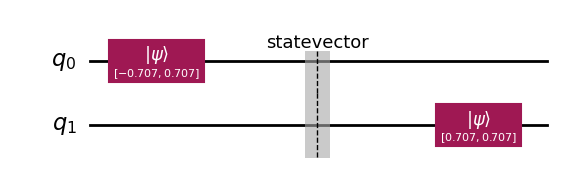

In [7]:
# 회로 그리기
qc.draw('mpl')
plt.show()

In [8]:
# AerSimulator용으로 회로 트랜스파일
simulator = AerSimulator()
transpiled_circuit = transpile(qc, simulator)

In [9]:
# 시뮬레이션 실행
result = simulator.run(transpiled_circuit).result()

In [10]:
# 상태벡터 얻기 (실험 데이터에서)
statevector = result.data()['statevector']

In [11]:
# 상태벡터 출력
# print("Statevector:", latex.latex(statevector))  # latex 표현 출력
print("Statevector:", statevector)

Statevector: Statevector([-0.70710678+0.j,  0.70710678+0.j, -0.        +0.j,
              0.        +0.j],
            dims=(2, 2))


In [12]:
# 모든 큐비트 측정
qc.measure_all()

In [13]:
# 측정이 포함된 회로를 트랜스파일해 실행
transpiled_circuit_with_measurement = transpile(qc, simulator)
result_with_measurement = simulator.run(transpiled_circuit_with_measurement, shots=1024).result()

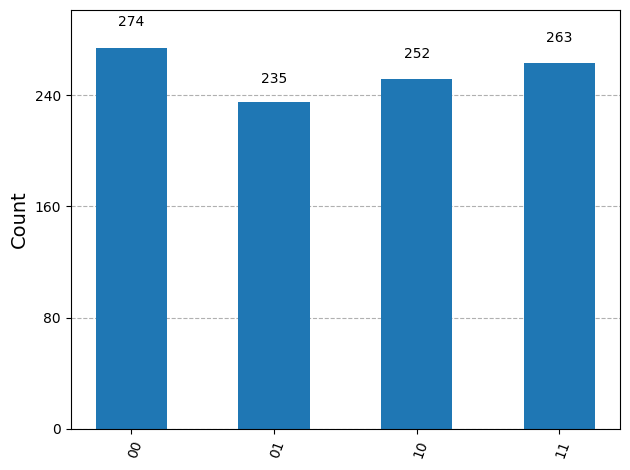

In [14]:
# 측정 결과 얻기
counts = result_with_measurement.get_counts()
plot_histogram(counts)
plt.show()